In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
import sys

# Ensure we can see your data
ANNOTATIONS_FILE = "../data/annotations.json"
IMAGES_DIRECTORY = "../data/images"

# Initialize COCO
coco = COCO(ANNOTATIONS_FILE)
img_ids = coco.getImgIds()
print(f"✅ Loaded {len(img_ids)} labeled images.")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✅ Loaded 4 labeled images.


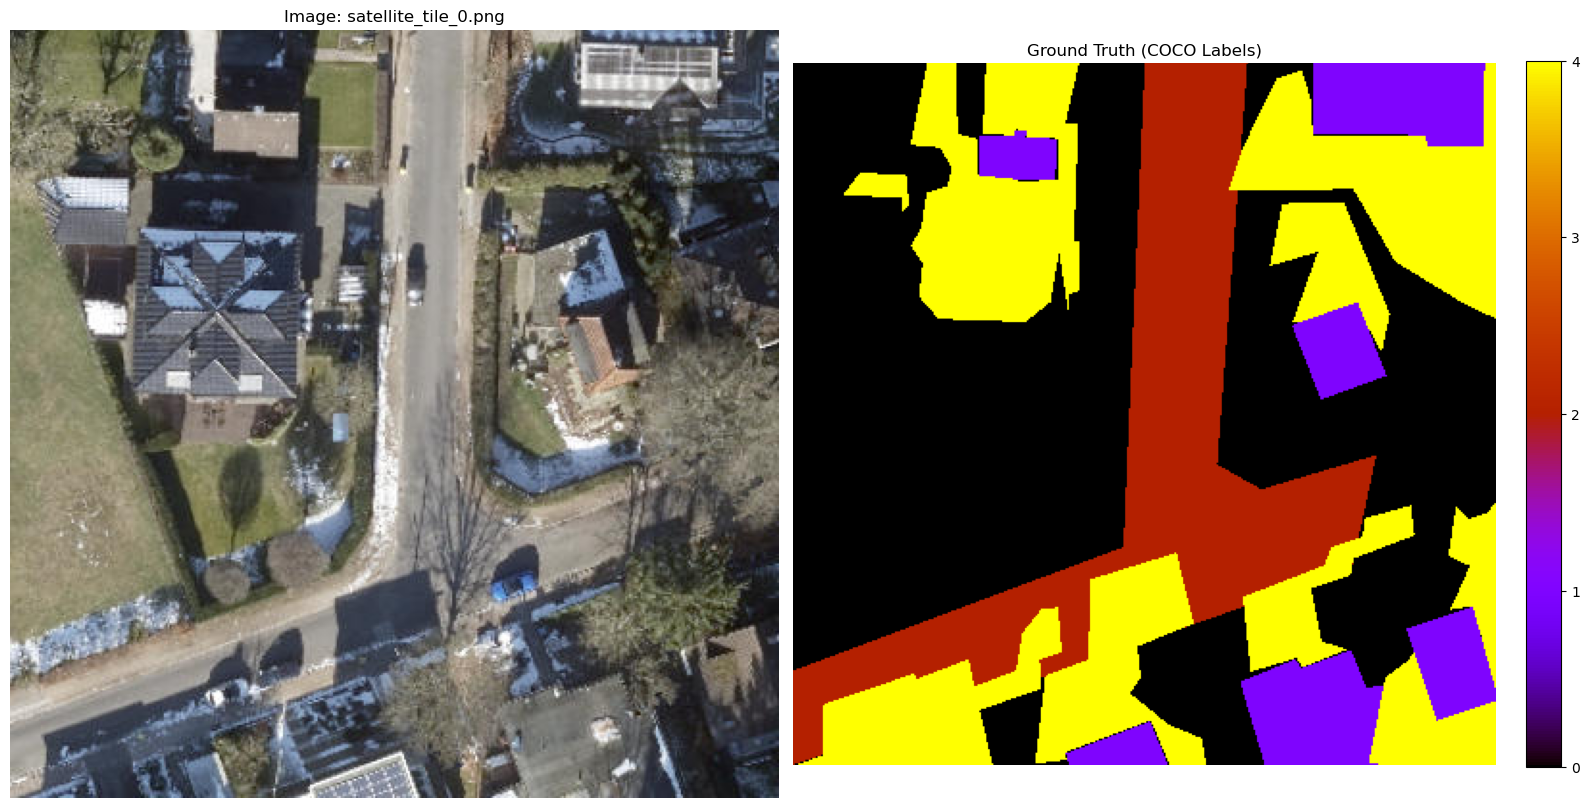

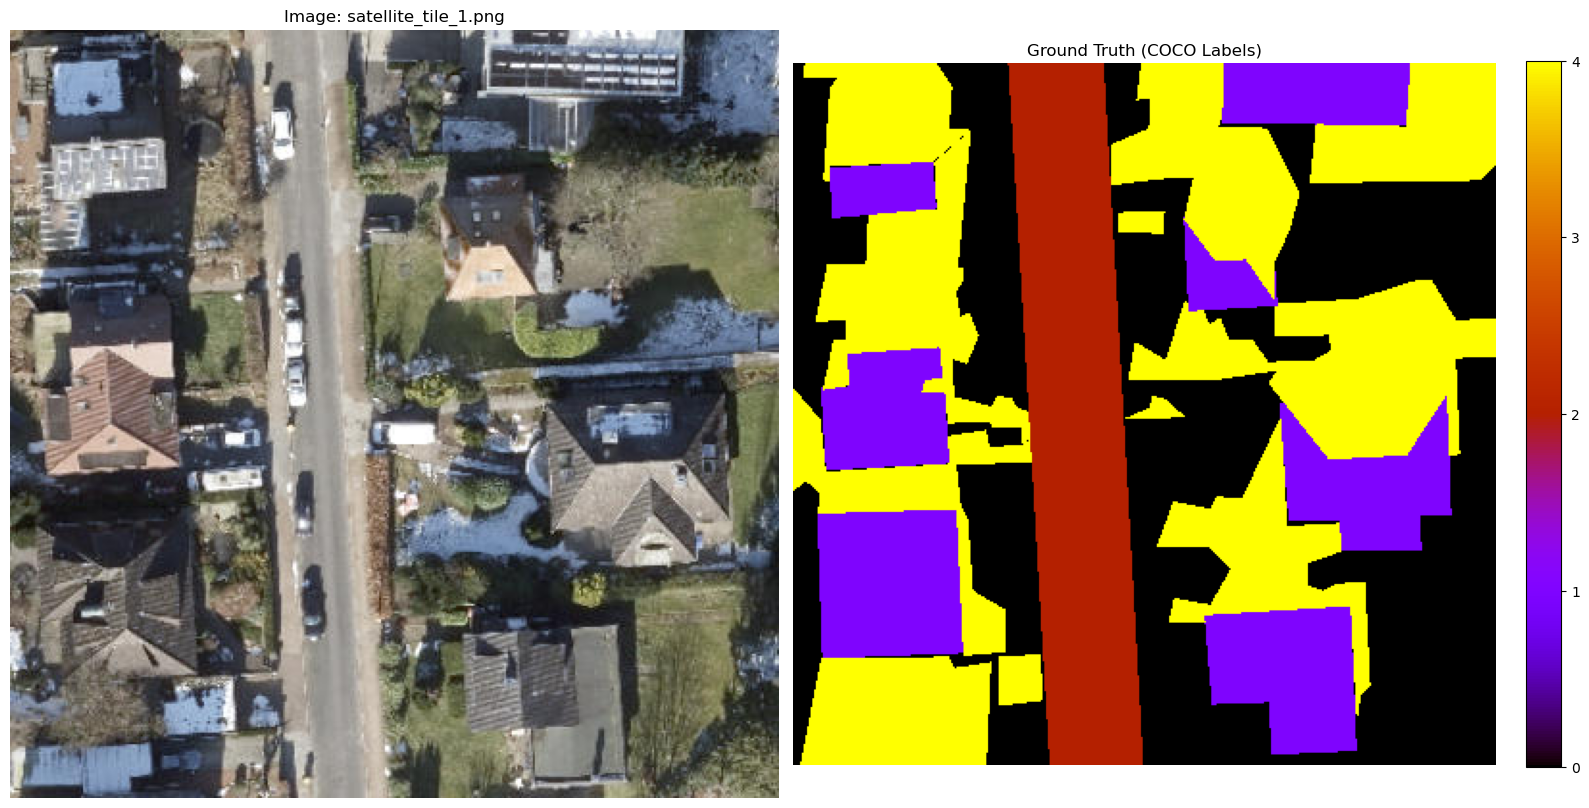

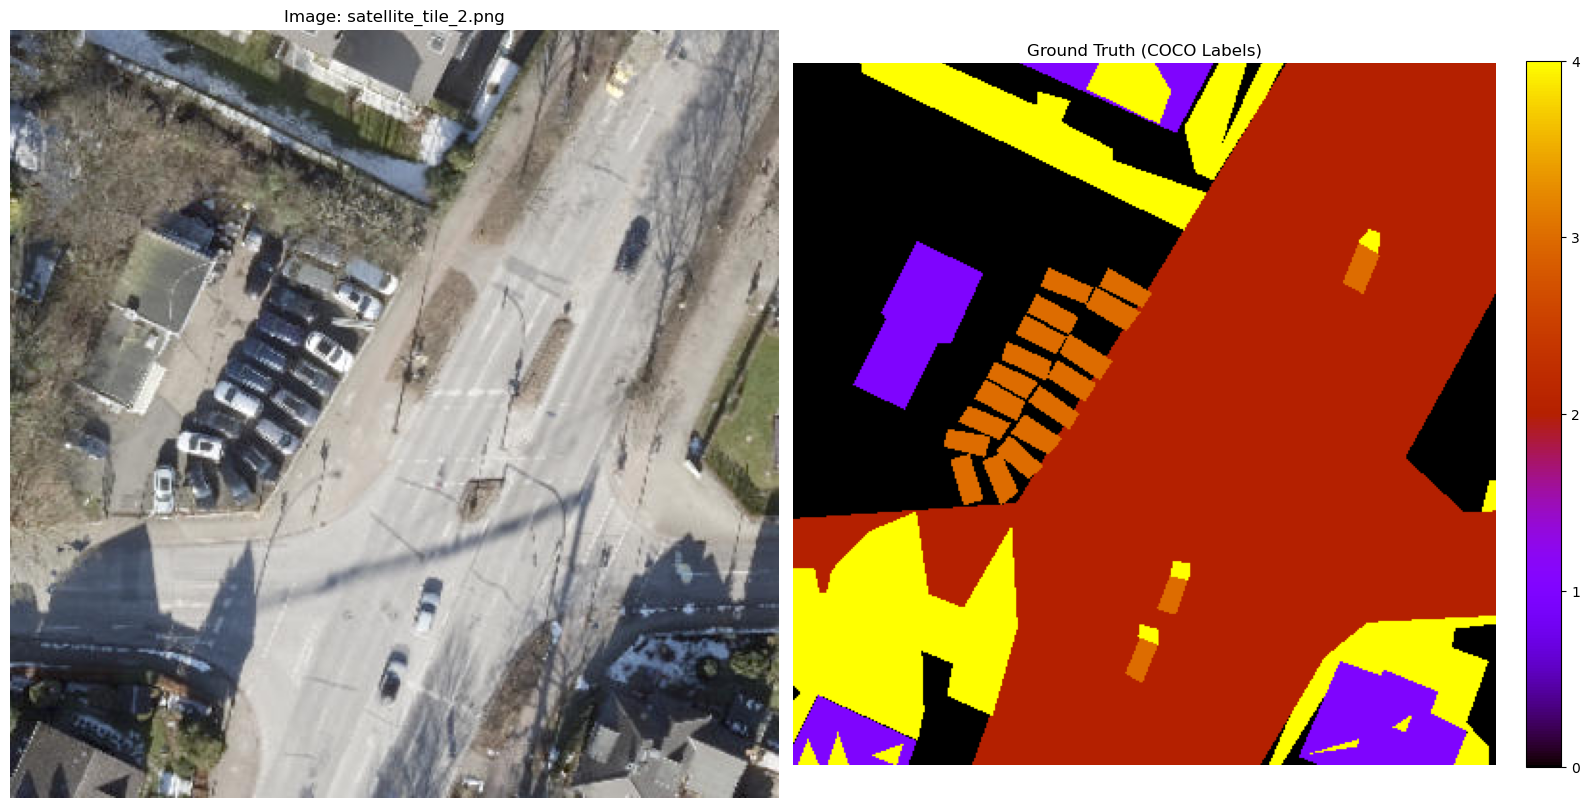

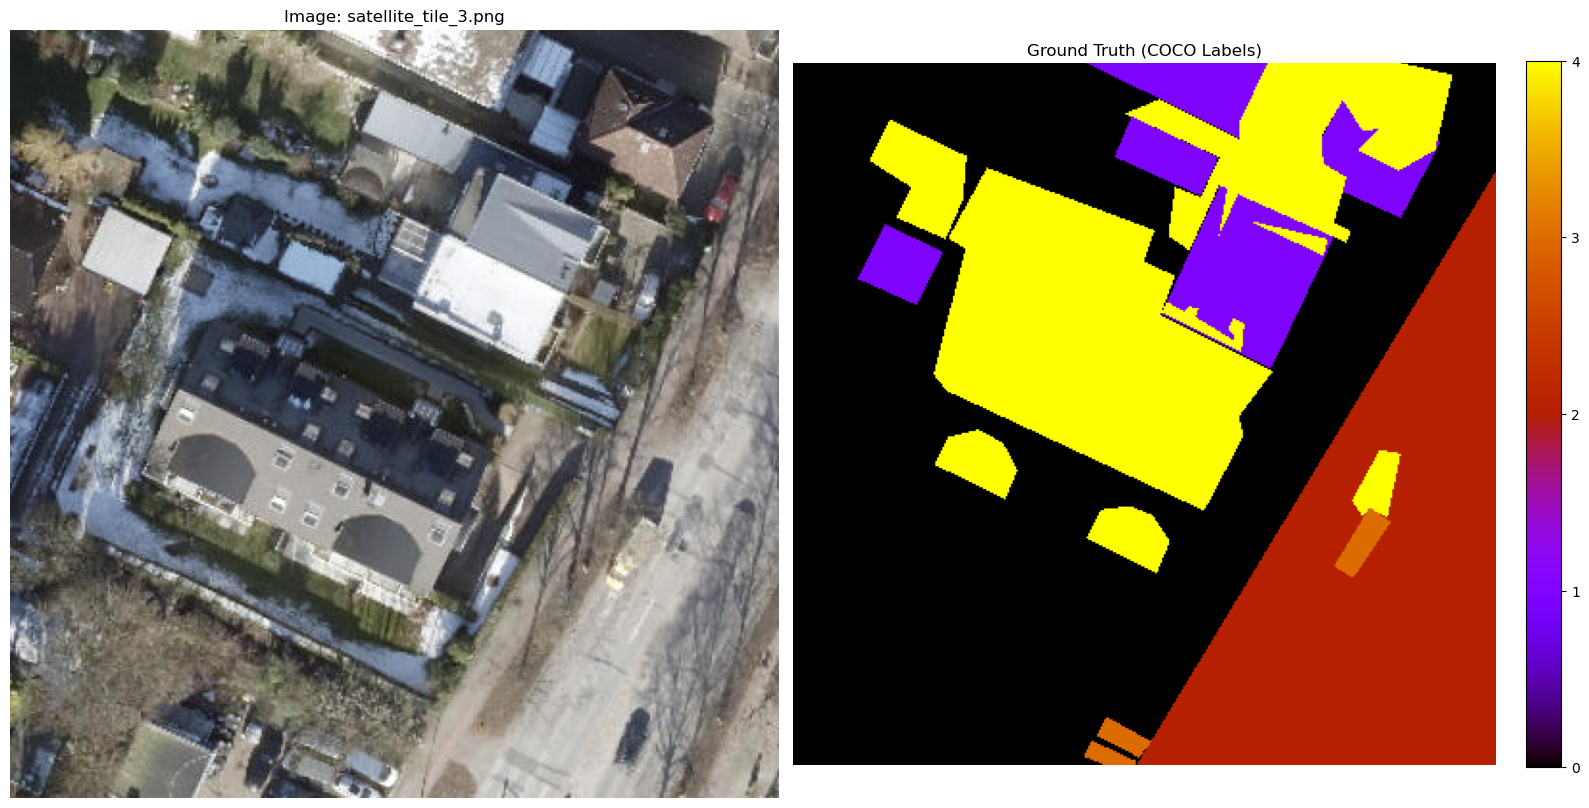

In [5]:
def visualize_all_labels():
    for img_id in img_ids:
        # 1. Load Metadata
        img_metadata = coco.loadImgs(img_id)[0]
        file_name = img_metadata['file_name']
        img_path = os.path.join(IMAGES_DIRECTORY, file_name)
        
        if not os.path.exists(img_path):
            continue

        # 2. Build the Mask from Polygons
        height, width = img_metadata['height'], img_metadata['width']
        mask = np.zeros((height, width), dtype=np.uint8)
        ann_ids = coco.getAnnIds(imgIds=img_id)
        annotations = coco.loadAnns(ann_ids)

        for ann in annotations:
            try:
                pixel_mask = coco.annToMask(ann)
                mask[pixel_mask == 1] = ann['category_id']
            except:
                continue

        # 3. Plotting the Outcome
        fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
        # Original Satellite
        ax[0].imshow(Image.open(img_path))
        ax[0].set_title(f"Image: {file_name}")
        ax[0].axis('off')

        # The Ground Truth Mask
        # cmap='gnuplot' or 'jet' makes the different classes (1, 2, 3) pop out
        im = ax[1].imshow(mask, cmap='gnuplot') 
        ax[1].set_title("Ground Truth (COCO Labels)")
        ax[1].axis('off')
        
        # Add a colorbar to show which ID is which
        plt.colorbar(im, ax=ax[1], ticks=range(len(coco.cats) + 1), fraction=0.046, pad=0.04)
        
        plt.tight_layout()
        plt.show()

# Run the visual check
visualize_all_labels()